# ejercicio 2: Procesamiento en pseudocolor
1. Habitualmente las im ́agenes que se relevan en partes no visibles del espectro
(como las de infrarrojos, radar, etc.) se encuentran en escala de grises. Para
resaltar zonas de inter ́es, se pueden asignar colores a rangos espec ́ıficos de inten-
sidades.
Para este ejercicio debe utilizar la imagen ‘rio.jpg’ y resaltar todas las  ́areas
con acumulaciones grandes de agua (r ́ıo central, ramas mayores y peque ̃nos la-
gos) en color amarillo.
A continuaci ́on le proponemos una gu ́ıa metodol ́ogica para resolver  ́esto, aunque
usted puede proponer otra:
- (a) analizar el histograma y estimar el rango de valores en el que se representa
el agua,
- (b) generar una imagen color cuyos canales son copia de la imagen de intensidad,
- (c) recorrer la imagen original y asignar el color amarillo a los p ́ıxeles cuyas
intensidades est ́an dentro del rango definido,
- (d) visualizar la imagen resultante y ajustar el rango de grises de ser necesario.
Consejo:  ́esto se hace m ́as simple utilizando trackbars.

In [1]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [2]:
def mostrar_horizontal(img_hsv1, img_hsv2, titulo1="Imagen 1", titulo2="Imagen 2"):
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    img_rgb1 = cv2.cvtColor(img_hsv1, cv2.COLOR_HSV2RGB)
    img_rgb2 = cv2.cvtColor(img_hsv2, cv2.COLOR_HSV2RGB)
    
    axs[0].imshow(img_rgb1)
    axs[0].set_title(titulo1)
    axs[0].axis("off")
    
    axs[1].imshow(img_rgb2)
    axs[1].set_title(titulo2)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()


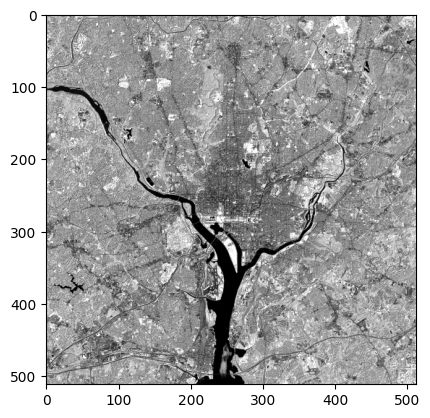

In [3]:
img = cv2.imread("../Imagenes_cursado/rio.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap = 'gray',vmin=0, vmax=255)
plt.show()

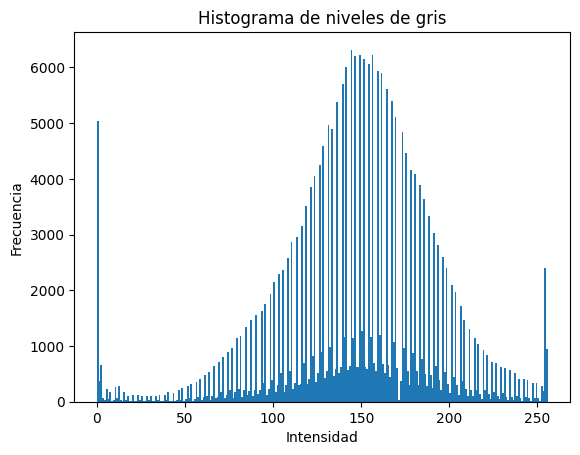

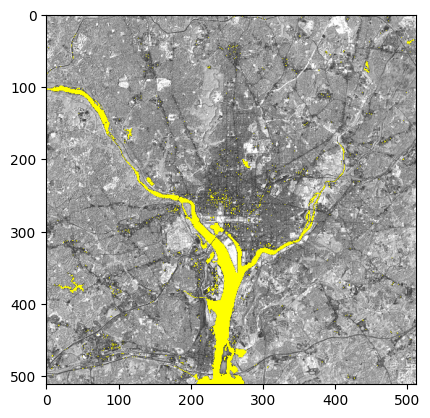

In [4]:
# analizamos histograma de frecuencia de los pixeles



plt.hist(img.ravel(), bins=256, range=[0,256])
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.title("Histograma de niveles de gris")
plt.show()

#elijo umbral de 10

V_new = img.copy()
S_new= np.ones_like(V_new) * 255
H_new= np.zeros_like(V_new)


umbral = 50


for i in range(V_new.shape[0]):
    for j in range(V_new.shape[1]):
        if (V_new[i,j]<umbral):
            H_new[i,j]= 30
            V_new [i,j]= 255
        else:
            S_new[i,j] = 0 #mantenemos la imagen en gris 

img_hsv_nueva = cv2.merge([H_new, S_new, V_new])

img_rgb = cv2.cvtColor(img_hsv_nueva, cv2.COLOR_HSV2RGB)
plt.imshow(img_rgb)
plt.show()

In [5]:
def resaltar_agua(img):
    
    @interact(
        umbral=IntSlider(
            min=0,
            max=255,
            step=1,
            value=50,
            description="Umbral"
        )
    )
    
    def actualizar(umbral):
        
        V_new = img.copy()
        S_new = np.ones_like(V_new) * 255
        H_new = np.zeros_like(V_new)
        
        for i in range(V_new.shape[0]):
            for j in range(V_new.shape[1]):
                
                if V_new[i,j] < umbral:
                    H_new[i,j] = 30      # amarillo
                    V_new[i,j] = 255     # hacerlo visible
                
                else:
                    S_new[i,j] = 0       # mantener gris
        
        img_hsv_nueva = cv2.merge([H_new, S_new, V_new])
        img_rgb = cv2.cvtColor(img_hsv_nueva, cv2.COLOR_HSV2RGB)
        
        plt.figure(figsize=(8,6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Umbral = {umbral}")
        plt.show()

In [ ]:
resaltar_agua(img)

interactive(children=(IntSlider(value=50, description='Umbral', max=255), Output()), _dom_classes=('widget-int…